<a href="https://colab.research.google.com/github/OscarEdy/Proyecto-Ciencia-de-Datos/blob/main/Proyecto_final_de_CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PASO 1 — Importar librerías**

In [1]:
import pandas as pd
import numpy as np

**PASO 2 — Cargar el archivo**

In [15]:
# Importamos la librería que permite conectar Google Drive con Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
# Leemos el archivo CSV desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/CD/ventas2025.csv', sep=';', on_bad_lines='warn')

**PASO** 3 — Ver la **estructura**

In [6]:
# verificamos que la data

df.head()

,Periodo_Año,Periodo_Mes,Documento_Estado,Pedido,Documento_Fecha,Documento_tipo,Documento_Serie,Documento_Numero,Cliente_Codigo,Cliente_Documento,...,IDItemComprobante,Agrupacion,Importe_ValorVenta,Cliente_Provincia,Cliente_Departamento,Vendedor_CodRuta,Producto_UME,ItemSaldo,CodigoSucursal,Sucursal
0,2025,1,ACTIVO,ComprobanteVenta/ B301-0021581,00:00.0,07 Nota de Crédito,B301,21581,6798,1874922,...,0,0,-12.423729,EL COLLAO,PUNO,107.0,-0.2700,0.0,1,CENTRAL
1,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,0.000000,SAN ROMAN,PUNO,NaN,0.0180,0.0,1,CENTRAL
2,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,28.000000,SAN ROMAN,PUNO,NaN,0.6000,0.0,1,CENTRAL
3,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,25.923729,SAN ROMAN,PUNO,NaN,0.5400,0.0,1,CENTRAL
4,2025,1,ACTIVO,Pedido/ B301-0924177,00:00.0,03 Boleta de Venta,B301,924177,9401,41542702,...,0,0,11.677966,SAN ROMAN,PUNO,NaN,0.0128,0.0,1,CENTRAL


In [17]:
# Mostramos cantidad de filas, cantidad de columnas, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451793 entries, 0 to 451792
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Periodo_Año            451793 non-null  int64  
 1   Periodo_Mes            451793 non-null  int64  
 2   Documento_Estado       451793 non-null  object 
 3   Pedido                 451793 non-null  object 
 4   Documento_Fecha        451793 non-null  object 
 5   Documento_tipo         451793 non-null  object 
 6   Documento_Serie        451793 non-null  object 
 7   Documento_Numero       451793 non-null  int64  
 8   Cliente_Codigo         451793 non-null  object 
 9   Cliente_Documento      451793 non-null  int64  
 10  Cliente_Distrito       451793 non-null  object 
 11  Cliente_Categoria      451793 non-null  object 
 12  Cliente_Giro           451793 non-null  object 
 13  Cliente_nombre         451793 non-null  object 
 14  Cliente_Direccion      451787 non-nu

In [20]:
# Cambiamos el nombre de la columna

df = df.rename(columns={
    'Periodo_Año': 'Año'
})

In [25]:
# Mostramos el tipo de dato de la columna Año

print(df['Año'].dtype)


int64


In [28]:
# Cambiamos el nombre de la columna

df = df.rename(columns={
    'Periodo_Mes': 'Mes'
})

In [30]:
# Mostramos el tipo de dato de la columna Año

print(df['Mes'].dtype)

int64


In [31]:
# CONVERTIR DOCUMENTO_ESTADO A BINARIO

df['Documento_Estado'] = df['Documento_Estado'].replace({
    'ACTIVO': 1,
    'ANULADO': 0
})

/tmp/ipykernel_2806/1362349638.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Documento_Estado'] = df['Documento_Estado'].replace({


In [35]:
# CONVERTIR A TIPO NUMÉRICO ENTERO
df['Documento_Estado'] = df['Documento_Estado'].astype(int)


In [37]:
# Convertimos la columna Documento_Fecha a formato fecha

df['Documento_Fecha'] = pd.to_datetime(df['Documento_Fecha'])

In [47]:
# SE ELIMINA LAS COLUMNAS QUE NO SE UTILIZARÁN

columns_to_drop = [
    'Documento_tipo',
    'Documento_Serie',
    'Documento_Numero',
    'Cliente_Direccion',
    'Almacen_Codigo',
    'Familia_Codigo',
    'Familia_Detalle',
    'Bonificacion',
    'Importe_Unitario',
    'FechaFacturacion',
    'PKID',
    'TipoItem',
    'Anulado',
    'CostoP',
    'CostoUC',
    'IDItemComprobante',
    'Agrupacion',
    'Vendedor_CodRuta',
    'Producto_UME',
    'ItemSaldo',
    'CodigoSucursal',
    'Sucursal',
    'Cliente_Documento',
    'Cliente_nombre',
    'Cliente_Direccion',

]

# Filtra las columnas que realmente existen en el DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Elimina solo las columnas existentes
df = df.drop(columns=existing_columns_to_drop)

In [49]:
# Muestra todas las columnas del dataset

df.columns


Index(['Año', 'Mes', 'Documento_Estado', 'Pedido', 'Documento_Fecha',
       'Cliente_Codigo', 'Cliente_Distrito', 'Cliente_Categoria',
       'Cliente_Giro', 'Almacen_Detalle', 'Categoria_codigo',
       'Categoria_detalle', 'subcategoria_codigo', 'subcategoria_detalle',
       'Producto_Codigo', 'Producto_Detalle', 'Producto_presentacion',
       'Producto_Cantidad', 'Importe_Total', 'Vendedor_Codigo',
       'Vendedor_Nombre', 'Vendedor_Ciudad', 'Proveedor', 'MotivoAnulacion',
       'Importe_ValorVenta', 'Cliente_Provincia', 'Cliente_Departamento'],
      dtype='object')

**ANALISIS DE DATASET**

***Evolución de ventas por mes***

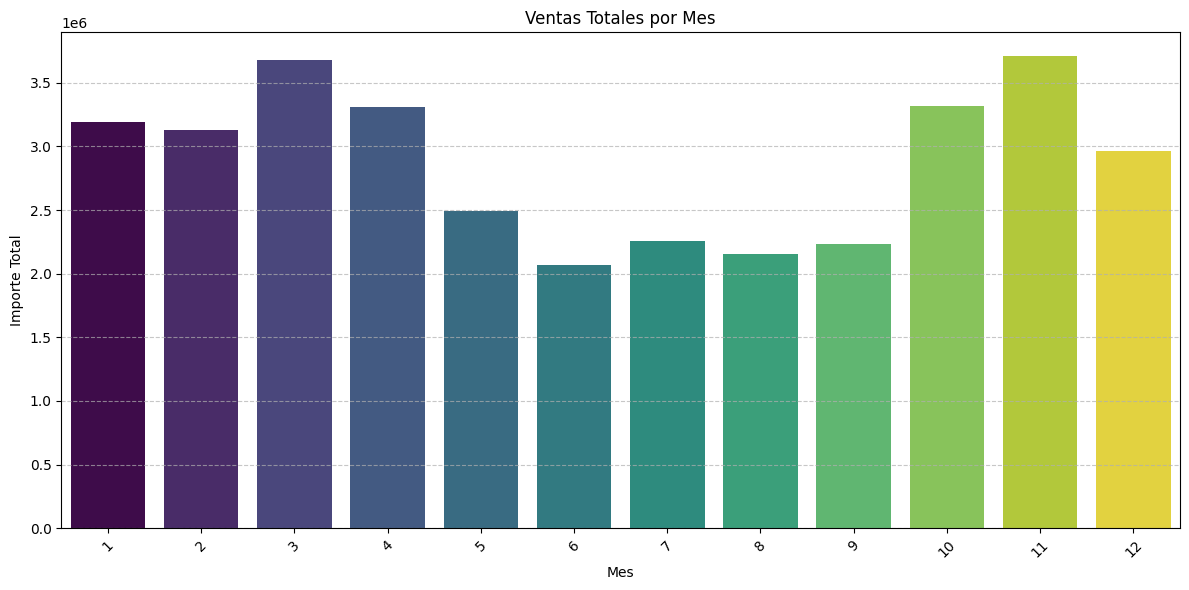

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar ventas por mes, solo para documentos activos (Documento_Estado = 1)
ventas_mes_activos = df[df['Documento_Estado'] == 1].groupby('Mes')['Importe_Total'].sum().reset_index()

# Crear gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='Mes', y='Importe_Total', hue='Mes', data=ventas_mes_activos, palette='viridis', legend=False)

# Títulos y etiquetas
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Importe Total')
plt.xticks(rotation=45) # Rotar etiquetas si es necesario
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar gráfico
plt.tight_layout()
plt.show()

***Top 10 Vendedores por Volumen de Ventas***

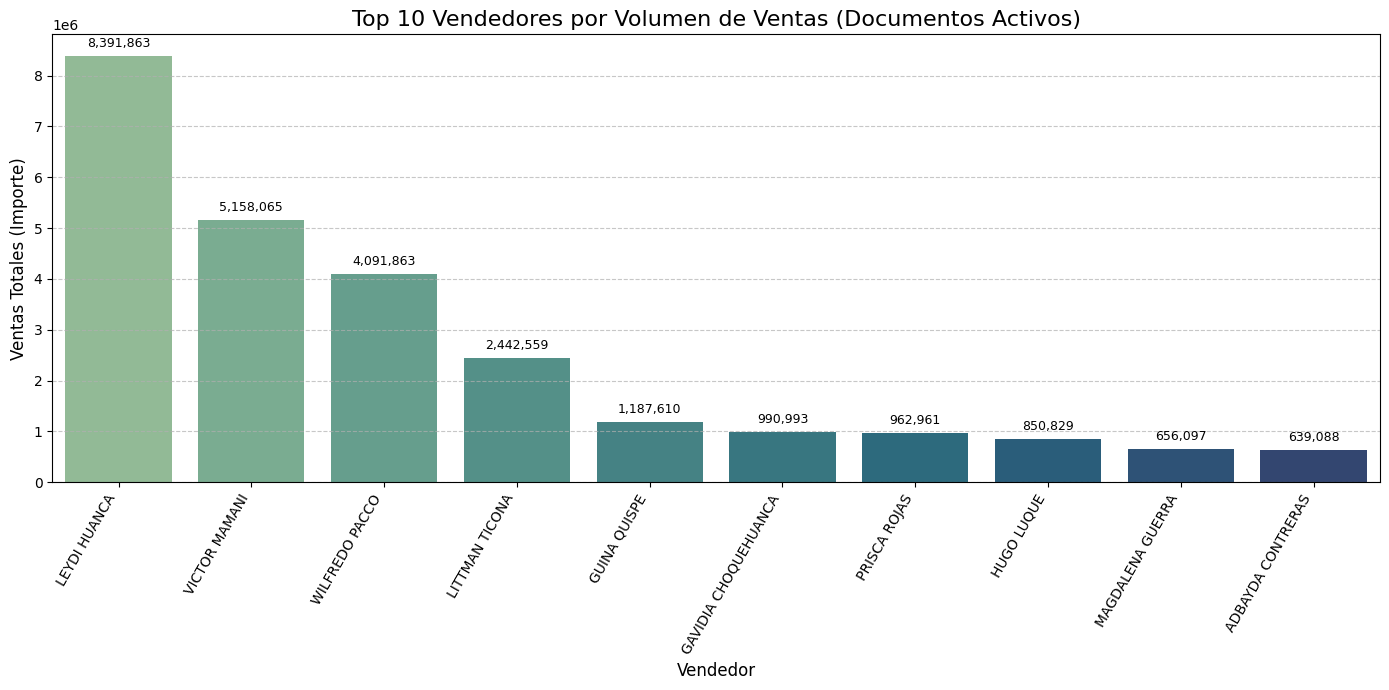

In [68]:
# Top vendedores (solo documentos activos)
top_vendedores = df[df['Documento_Estado'] == 1].groupby('Vendedor_Nombre')['Importe_Total'].sum()

# Ordenar y seleccionar el top 10
top_vendedores = top_vendedores.sort_values(ascending=False).head(10)

# Gráfico mejorado con Seaborn
plt.figure(figsize=(14, 7)) # Aumentar tamaño para mejor visibilidad
ax = sns.barplot(x=top_vendedores.index, y=top_vendedores.values,
                 palette='crest', hue=top_vendedores.index, legend=False)

# Títulos y etiquetas
plt.title('Top 10 Vendedores por Volumen de Ventas (Documentos Activos)', fontsize=16)
plt.xlabel('Vendedor', fontsize=12)
plt.ylabel('Ventas Totales (Importe)', fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas para evitar solapamiento
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', # Formatear el número sin decimales y con comas
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

***Gráfico de dispersión para comparar Importe y Mes***


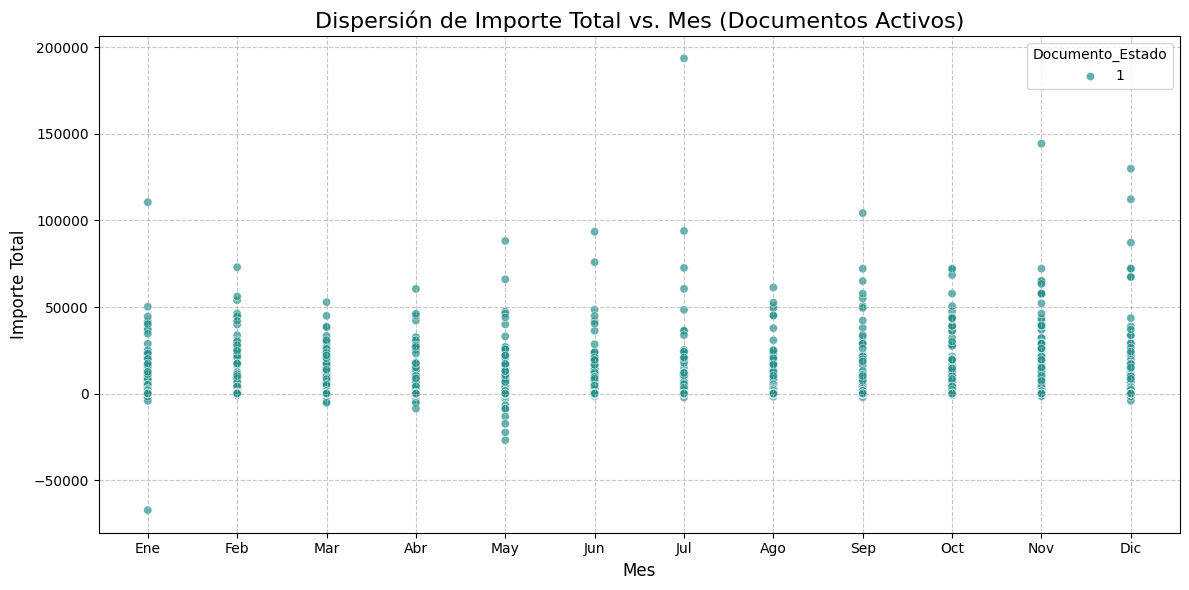

In [69]:
# Gráfico de dispersión para comparar Importe_Total y Mes (solo documentos activos)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Mes', y='Importe_Total', hue='Documento_Estado', data=df[df['Documento_Estado'] == 1], palette='viridis', alpha=0.7)

# Títulos y etiquetas
plt.title('Dispersión de Importe Total vs. Mes (Documentos Activos)', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']) # Etiquetas de meses más amigables

plt.tight_layout()
plt.show()

***Productos más vendidos***



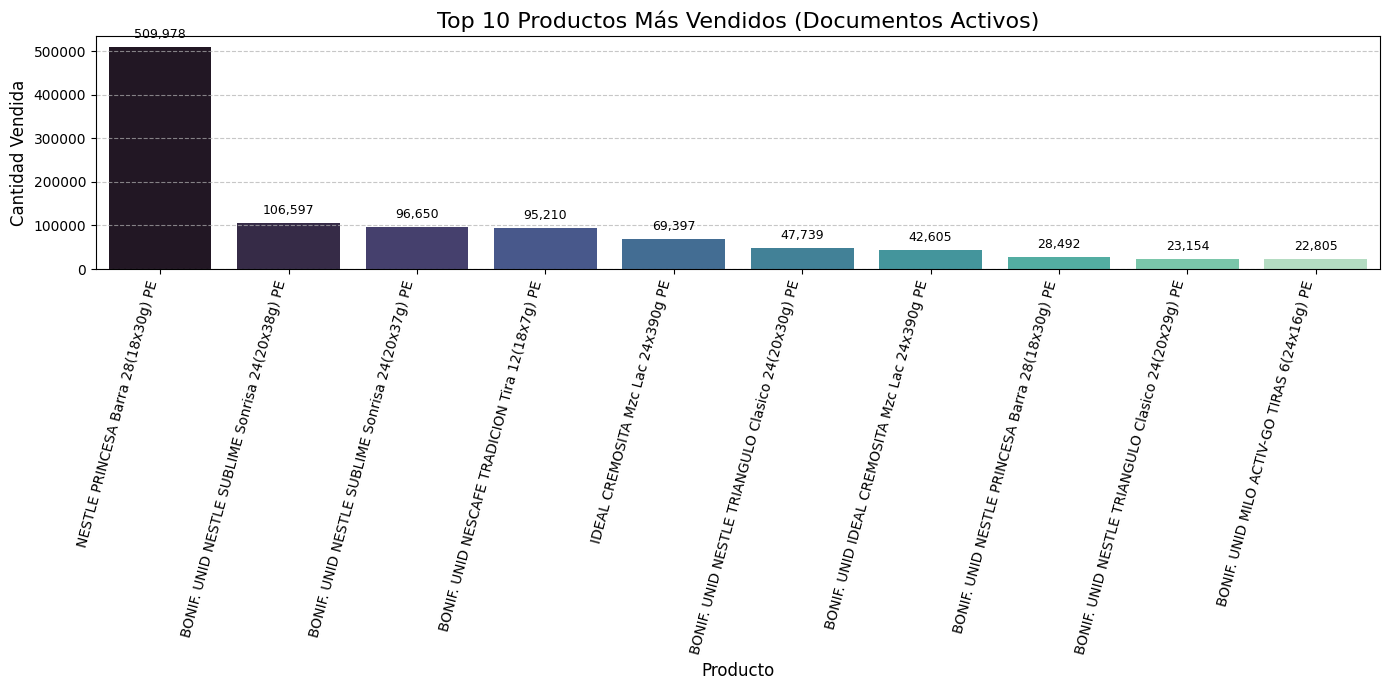

In [70]:
# Productos más vendidos (solo documentos activos)
productos = df[df['Documento_Estado'] == 1].groupby('Producto_Detalle')['Producto_Cantidad'].sum()

# Top 10
productos = productos.sort_values(ascending=False).head(10)

# Gráfico mejorado con Seaborn
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=productos.index, y=productos.values,
                 palette='mako', hue=productos.index, legend=False)

# Títulos y etiquetas
plt.title('Top 10 Productos Más Vendidos (Documentos Activos)', fontsize=16)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=75, ha='right', fontsize=10) # Rotar más las etiquetas
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() # Ajustar el diseño
plt.show()

***Top 10 Provincias con Mayor Volumen de Ventas***

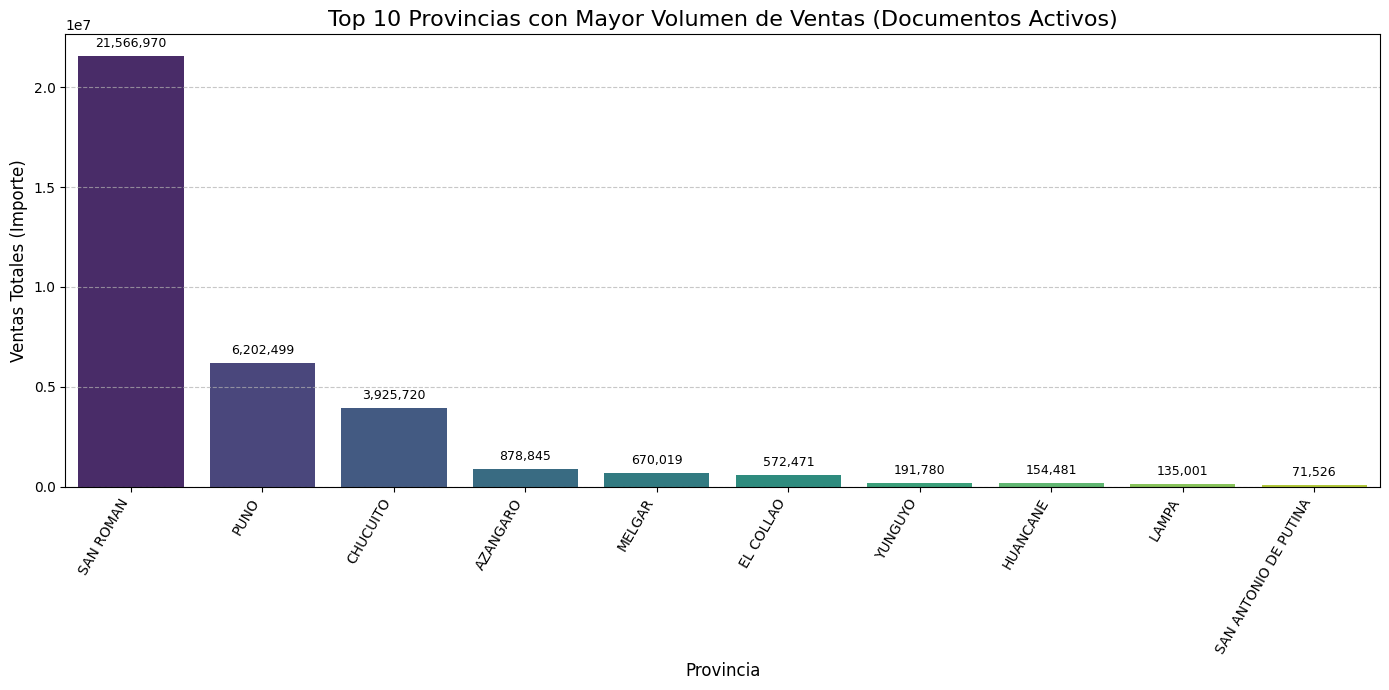

In [64]:
# Ventas por provincia
ventas_departamento = df[df['Documento_Estado'] == 1].groupby('Cliente_Provincia')['Importe_Total'].sum()

# Top provincia
ventas_departamento = ventas_departamento.sort_values(ascending=False).head(10)

# Gráfico mejorado con Seaborn
plt.figure(figsize=(14, 7)) # Aumentar tamaño para mejor visibilidad de etiquetas
ax = sns.barplot(x=ventas_departamento.index, y=ventas_departamento.values,
                 palette='viridis', hue=ventas_departamento.index, legend=False)

# Títulos y etiquetas
plt.title('Top 10 Provincias con Mayor Volumen de Ventas (Documentos Activos)', fontsize=16)
plt.xlabel('Provincia', fontsize=12)
plt.ylabel('Ventas Totales (Importe)', fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas para evitar solapamiento
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', # Formatear el número sin decimales y con comas
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

In [72]:
print(f"El departamento con el mayor volumen de ventas es: {ventas_departamento.index[0]} con un total de {ventas_departamento.iloc[0]:,.2f}")

El departamento con el mayor volumen de ventas es: SAN ROMAN con un total de 21,566,969.81


***La categoría con el mayor volumen***

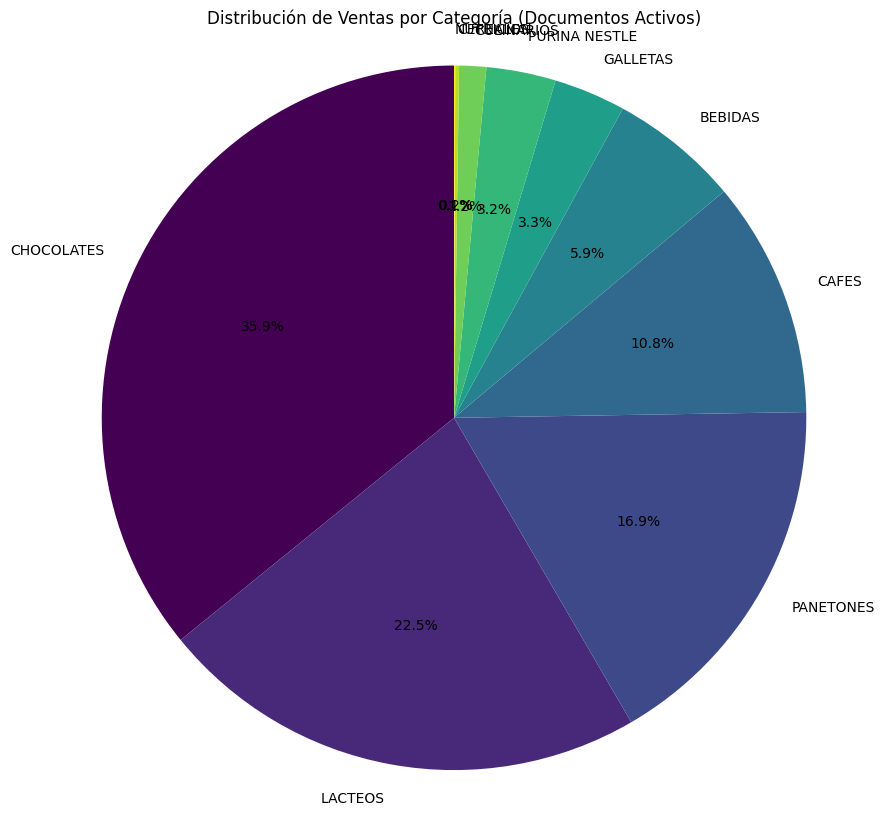

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Generar colores de la paleta 'viridis'
colors = plt.cm.viridis(np.linspace(0, 1, len(categorias.index)))

plt.pie(categorias.values, labels=categorias.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribución de Ventas por Categoría (Documentos Activos)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [76]:
print(f"La categoría con el mayor volumen de ventas es: {categorias.index[0]} con un total de {categorias.iloc[0]:,.2f}")

La categoría con el mayor volumen de ventas es: CHOCOLATES con un total de 12,373,593.61


***Categoría más vendida por mes***

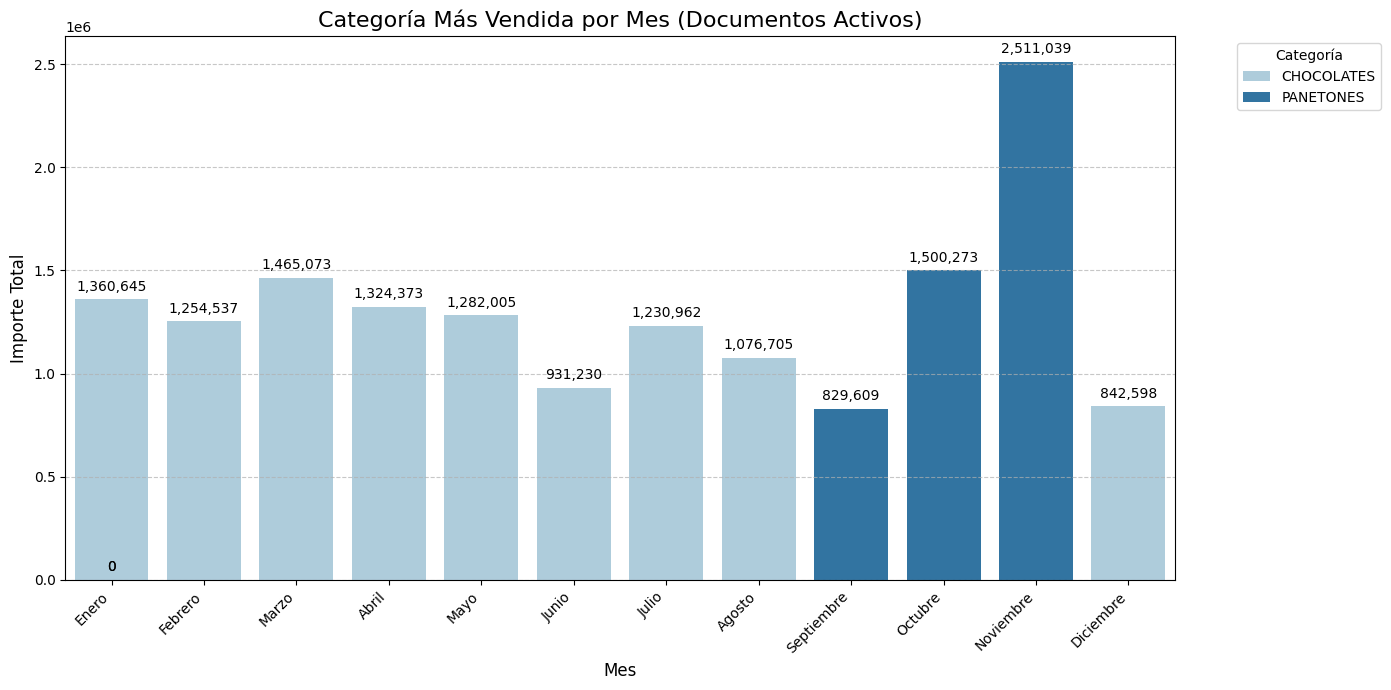

In [81]:
# Filtrar solo documentos activos
df_activos = df[df['Documento_Estado'] == 1]

# Agrupar por mes y categoría, y sumar el Importe_Total
ventas_por_mes_categoria = df_activos.groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar la categoría con mayor venta por cada mes
idx = ventas_por_mes_categoria.groupby('Mes')['Importe_Total'].idxmax()
mejor_categoria_por_mes = ventas_por_mes_categoria.loc[idx].reset_index(drop=True)

# Mapear los números de mes a nombres para una mejor visualización
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
               7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
mejor_categoria_por_mes['Mes_Nombre'] = mejor_categoria_por_mes['Mes'].map(month_names)

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(x='Mes_Nombre', y='Importe_Total', hue='Categoria_detalle', data=mejor_categoria_por_mes, palette='Paired', dodge=False)

# Añadir etiquetas de valor a las barras
ax = plt.gca() # Get current axes
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

plt.title('Categoría Más Vendida por Mes (Documentos Activos)', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

***Categorías más vendida por mes en SAN ROMAN***

/tmp/ipykernel_2806/3224005905.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  san_roman_top_3_monthly = san_roman_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)


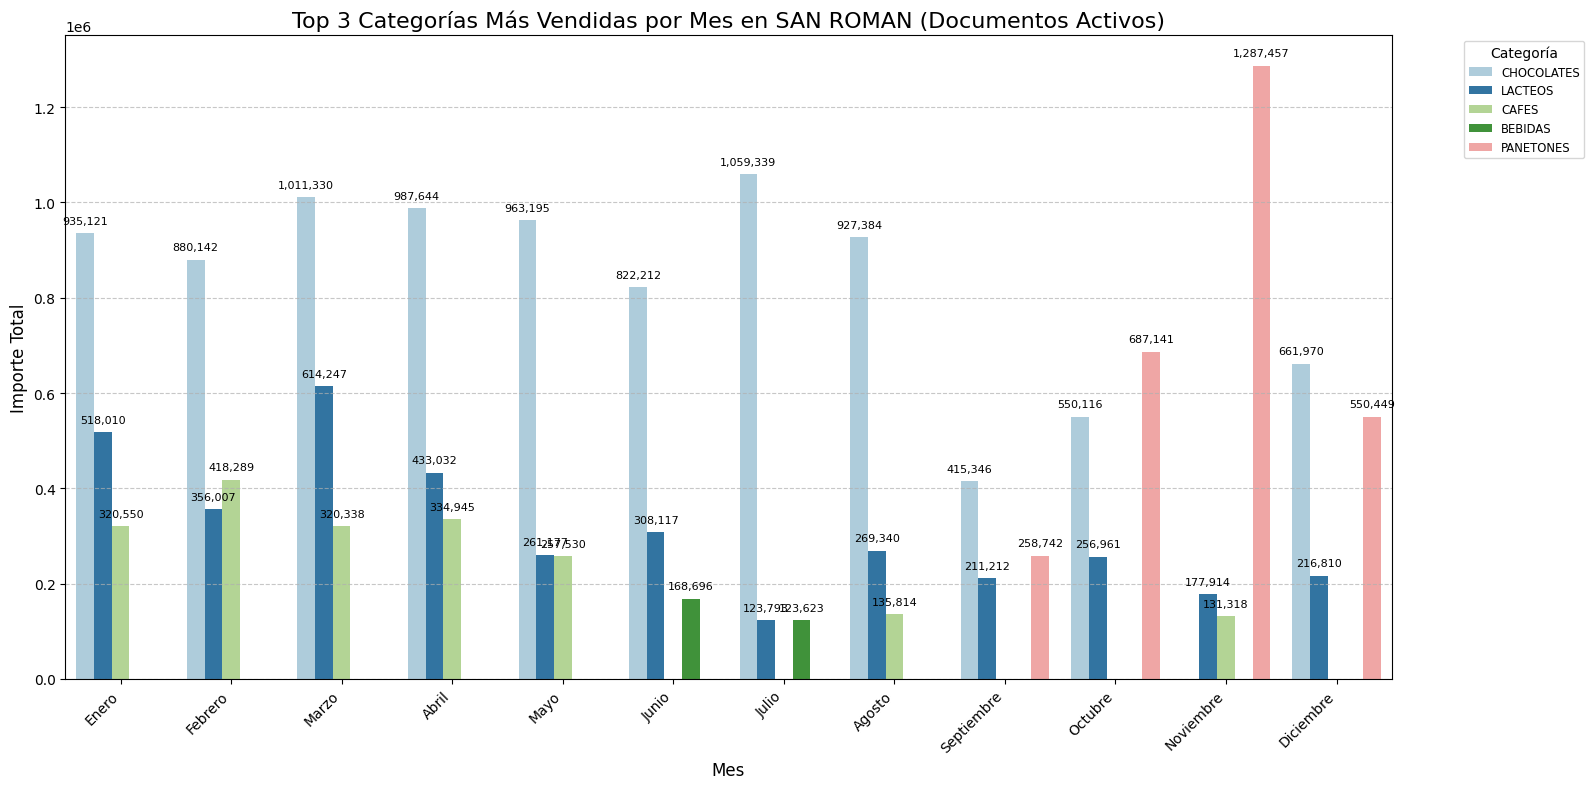

In [90]:
# Filtrar los datos para la provincia de SAN ROMAN y agrupar por mes y categoría
san_roman_data_grouped = df_activos[df_activos['Cliente_Provincia'] == 'SAN ROMAN'].groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar las top 3 categorías por mes en SAN ROMAN
san_roman_top_3_monthly = san_roman_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)

# Mapear los números de mes a nombres para una mejor visualización
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
               7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
san_roman_top_3_monthly['Mes_Nombre'] = san_roman_top_3_monthly['Mes'].map(month_names)

# Crear el gráfico de barras para SAN ROMAN con las top 3 categorías
plt.figure(figsize=(16, 8))
sns.barplot(x='Mes_Nombre', y='Importe_Total', hue='Categoria_detalle', data=san_roman_top_3_monthly, palette='Paired', dodge=True)

# Añadir etiquetas de valor a las barras
ax = plt.gca() # Get current axes
for p in ax.patches:
    if p.get_height() > 0: # Solo añadir etiquetas a barras con valor positivo
        ax.annotate(f'{p.get_height():,.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=8)

plt.title('Top 3 Categorías Más Vendidas por Mes en SAN ROMAN (Documentos Activos)', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

***Categorías más vendida por mes en Puno***

/tmp/ipykernel_2806/1867949272.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  puno_top_3_monthly = puno_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)


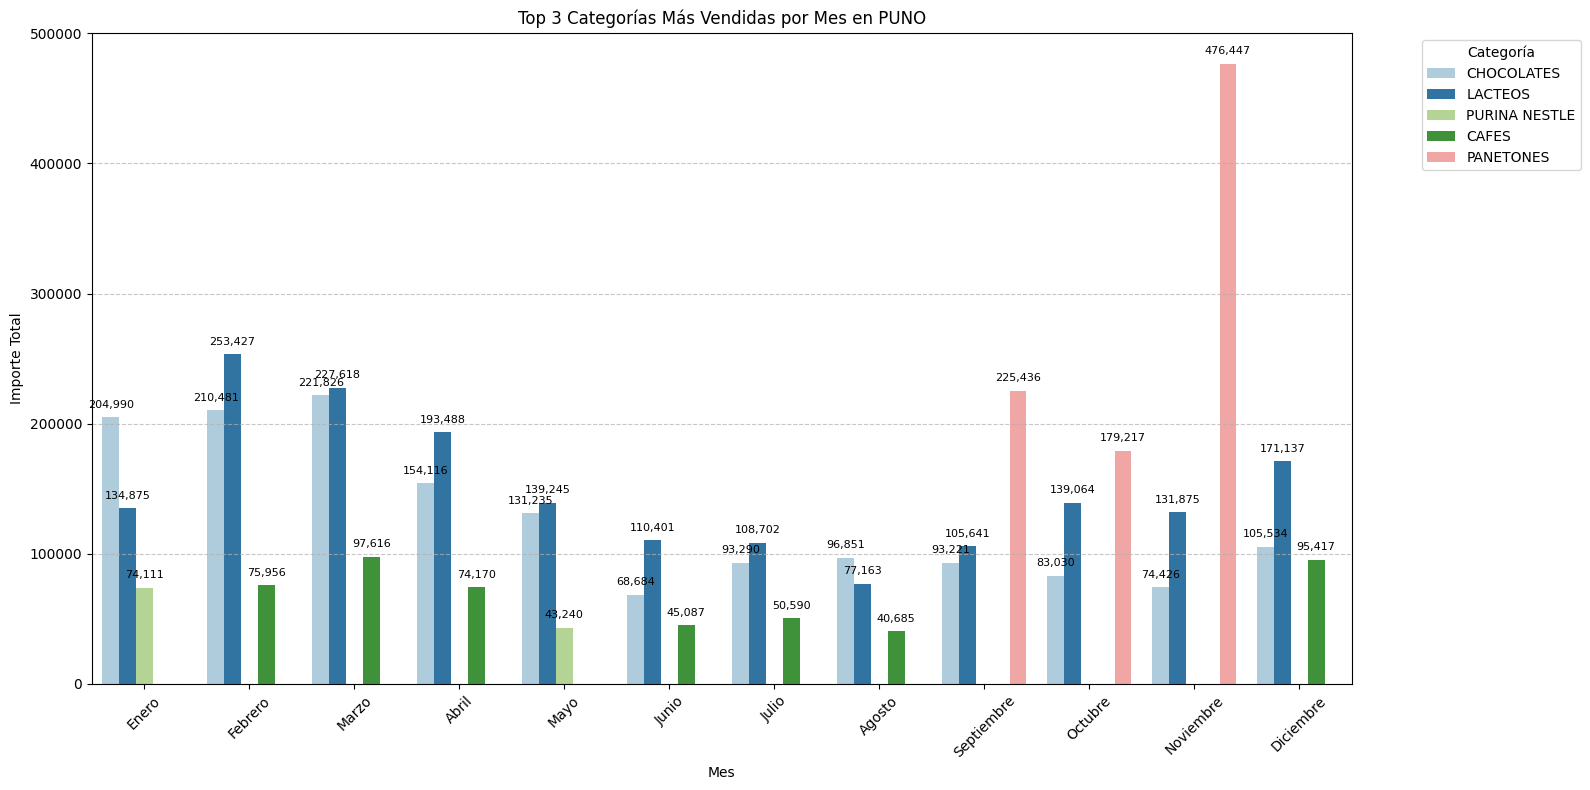

In [91]:
# Filtrar los datos para la provincia de PUNO y agrupar por mes y categoría
puno_data_grouped = df_activos[df_activos['Cliente_Provincia'] == 'PUNO'].groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar las top 3 categorías por mes en PUNO
puno_top_3_monthly = puno_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)

# Mapear números de mes a nombres
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

puno_top_3_monthly['Mes_Nombre'] = puno_top_3_monthly['Mes'].map(month_names)

# Crear gráfico
plt.figure(figsize=(16, 8))

sns.barplot(
    x='Mes_Nombre',
    y='Importe_Total',
    hue='Categoria_detalle',
    data=puno_top_3_monthly,
    palette='Paired'
)

# Etiquetas en barras
ax = plt.gca()

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():,.0f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=8
        )

# Personalizar gráfico
plt.title('Top 3 Categorías Más Vendidas por Mes en PUNO')
plt.xlabel('Mes')
plt.ylabel('Importe Total')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()